<a href="https://colab.research.google.com/github/Railyng/Clasificador-de-Sentimientos---BellezaNatural/blob/main/ClasificadorDeSentimientos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clasificador de Sentimientos - BellezaNatural**

Este proyecto tiene como objetivo desarrollar un sistema capaz de analizar comentarios de clientes y clasificarlos como positivos, negativos o neutros utilizando técnicas de Procesamiento de Lenguaje Natural (NLP) y Redes Neuronales.

In [27]:
import pandas as pd  # Para manejar datos en forma de tabla (DataFrame)
import numpy as np   # Para operaciones matemáticas y manejo de arreglos
import re            # Para limpiar texto usando expresiones regulares

import nltk          # Librería para procesamiento de lenguaje natural

# Herramientas de Machine Learning
from sklearn.model_selection import train_test_split  # Para dividir datos
from sklearn.preprocessing import LabelEncoder        # Para convertir texto a números
from sklearn.metrics import classification_report     # Para evaluar el modelo

# Librería para gráficos
import matplotlib.pyplot as plt  # Para crear gráficas

# Librerías de Deep Learning
from tensorflow.keras.models import Sequential        # Para crear la red neuronal
from tensorflow.keras.layers import Dense, Embedding, Flatten  # Capas de la red
from tensorflow.keras.preprocessing.text import Tokenizer       # Convertir texto a números
from tensorflow.keras.preprocessing.sequence import pad_sequences  # Igualar tamaños de texto

In [28]:
# DATASET

data = {
    "comentario": [
        # POSITIVOS
        "El producto es excelente",
        "Me encantó este producto",
        "Muy buena calidad",
        "Funciona perfectamente",
        "Lo recomiendo mucho",

        # NEGATIVOS
        "Muy mala calidad",
        "No me gustó para nada",
        "Pésimo producto",
        "No sirve",
        "Muy decepcionante",

        # NEUTROS
        "Está bien",
        "Es normal",
        "Nada especial",
        "Regular",
        "Puede mejorar"
    ],
    "sentimiento": [
        "positivo","positivo","positivo","positivo","positivo",
        "negativo","negativo","negativo","negativo","negativo",
        "neutro","neutro","neutro","neutro","neutro"
    ]
}

# Convertir a DataFrame
df = pd.DataFrame(data)

print("Dataset:")
print(df)

Dataset:
                  comentario sentimiento
0   El producto es excelente    positivo
1   Me encantó este producto    positivo
2          Muy buena calidad    positivo
3     Funciona perfectamente    positivo
4        Lo recomiendo mucho    positivo
5           Muy mala calidad    negativo
6      No me gustó para nada    negativo
7            Pésimo producto    negativo
8                   No sirve    negativo
9          Muy decepcionante    negativo
10                 Está bien      neutro
11                 Es normal      neutro
12             Nada especial      neutro
13                   Regular      neutro
14             Puede mejorar      neutro


In [29]:
# Función para limpiar texto
def limpiar_texto(texto):
    texto = texto.lower()  # Convertir a minúsculas
    texto = re.sub(r'[^a-záéíóúñ ]', '', texto)  # Eliminar símbolos
    return texto

# Aplicamos la limpieza a todos los comentarios
df["comentario"] = df["comentario"].apply(limpiar_texto)

# Mostramos resultado
print("\nDataset limpio:")
print(df)


Dataset limpio:
                  comentario sentimiento
0   el producto es excelente    positivo
1   me encantó este producto    positivo
2          muy buena calidad    positivo
3     funciona perfectamente    positivo
4        lo recomiendo mucho    positivo
5           muy mala calidad    negativo
6      no me gustó para nada    negativo
7            pésimo producto    negativo
8                   no sirve    negativo
9          muy decepcionante    negativo
10                 está bien      neutro
11                 es normal      neutro
12             nada especial      neutro
13                   regular      neutro
14             puede mejorar      neutro


In [30]:
# Creamos el tokenizador (máximo 1000 palabras)
tokenizer = Tokenizer(num_words=1000)

# Aprende el vocabulario del dataset
tokenizer.fit_on_texts(df["comentario"])

# Convierte texto en números
secuencias = tokenizer.texts_to_sequences(df["comentario"])

# Igualamos longitud de los textos (padding)
X = pad_sequences(secuencias, maxlen=10)

# Mostramos resultado
print("\nTexto convertido a números:")
print(X)


Texto convertido a números:
[[ 0  0  0  0  0  0  8  1  3  9]
 [ 0  0  0  0  0  0  4 10 11  1]
 [ 0  0  0  0  0  0  0  2 12  5]
 [ 0  0  0  0  0  0  0  0 13 14]
 [ 0  0  0  0  0  0  0 15 16 17]
 [ 0  0  0  0  0  0  0  2 18  5]
 [ 0  0  0  0  0  6  4 19 20  7]
 [ 0  0  0  0  0  0  0  0 21  1]
 [ 0  0  0  0  0  0  0  0  6 22]
 [ 0  0  0  0  0  0  0  0  2 23]
 [ 0  0  0  0  0  0  0  0 24 25]
 [ 0  0  0  0  0  0  0  0  3 26]
 [ 0  0  0  0  0  0  0  0  7 27]
 [ 0  0  0  0  0  0  0  0  0 28]
 [ 0  0  0  0  0  0  0  0 29 30]]


In [31]:
# Creamos el codificador
encoder = LabelEncoder()

# Convertimos etiquetas (positivo, negativo, neutro) a números
y = encoder.fit_transform(df["sentimiento"])

# Mostramos etiquetas
print("\nEtiquetas codificadas:")
print(y)


Etiquetas codificadas:
[2 2 2 2 2 0 0 0 0 0 1 1 1 1 1]


In [32]:
# Dividimos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nDatos de entrenamiento:", len(X_train))
print("Datos de prueba:", len(X_test))


Datos de entrenamiento: 12
Datos de prueba: 3


In [33]:
# Creamos modelo secuencial
model = Sequential()

# Embedding (representación de palabras)
model.add(Embedding(input_dim=1000, output_dim=32, input_length=10))

# Aplanar datos
model.add(Flatten())

# Capas ocultas (más potentes)
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

# Capa de salida (3 clases)
model.add(Dense(3, activation='softmax'))

# Compilar modelo
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Entrenamos el modelo con los datos
history = model.fit(
    X_train,          # Datos de entrada
    y_train,          # Etiquetas
    epochs=10,        # Número de iteraciones
    validation_data=(X_test, y_test)  # Validación
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4167 - loss: 1.0965 - val_accuracy: 0.3333 - val_loss: 1.1010
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.3333 - loss: 1.0927 - val_accuracy: 0.3333 - val_loss: 1.1010
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.5833 - loss: 1.0889 - val_accuracy: 0.3333 - val_loss: 1.1014
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.5000 - loss: 1.0853 - val_accuracy: 0.3333 - val_loss: 1.1018
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step - accuracy: 0.7500 - loss: 1.0820 - val_accuracy: 0.3333 - val_loss: 1.1014
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.8333 - loss: 1.0782 - val_accuracy: 0.3333 - val_loss: 1.1020
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8333 - loss: 1.0748 - val_accuracy: 0.3333 - val_loss: 1.1026
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.9167 - loss: 1.0710 - val_accuracy: 0.3333 - val_loss: 1.

In [35]:
# Hacemos predicciones
y_pred = model.predict(X_test)

# Convertimos probabilidades a clases
y_pred_classes = np.argmax(y_pred, axis=1)

# Mostramos métricas
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


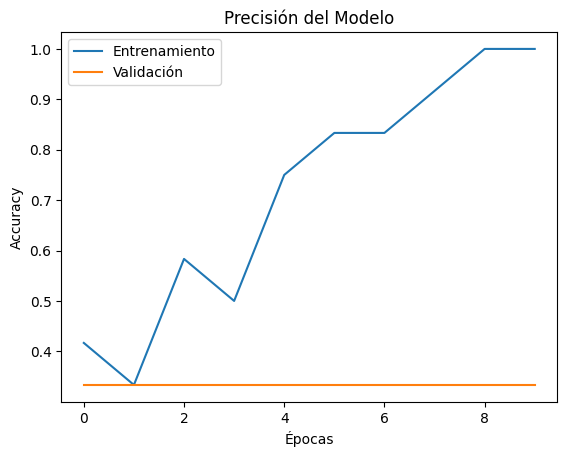

In [36]:
# Extraemos datos del entrenamiento
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Creamos la gráfica
plt.figure()
plt.plot(train_acc)
plt.plot(val_acc)

# Etiquetas
plt.title("Precisión del Modelo")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend(["Entrenamiento", "Validación"])

# Mostrar gráfica
plt.show()

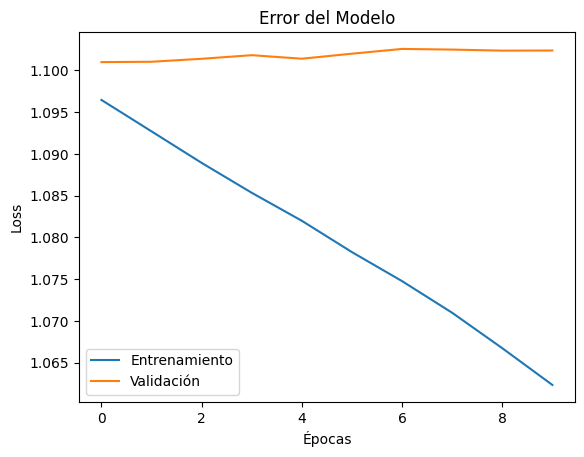

In [37]:
# Extraemos datos
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Creamos la gráfica
plt.figure()
plt.plot(train_loss)
plt.plot(val_loss)

# Etiquetas
plt.title("Error del Modelo")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend(["Entrenamiento", "Validación"])

# Mostrar gráfica
plt.show()

In [38]:
# Función para predecir sentimiento
def predecir_sentimiento(texto):
    texto = limpiar_texto(texto)  # Limpiar texto
    seq = tokenizer.texts_to_sequences([texto])  # Convertir a números
    padded = pad_sequences(seq, maxlen=10)  # Ajustar tamaño

    pred = model.predict(padded)
    clase = np.argmax(pred)

    # Convertir número a etiqueta
    return encoder.inverse_transform([clase])[0]

# Probamos el sistema
print("\nPruebas manuales:")
print(predecir_sentimiento("Me encantó este producto"))
print(predecir_sentimiento("Muy mal"))
print(predecir_sentimiento("Está regular"))


Pruebas manuales:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
positivo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
negativo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
neutro


## **Conclusión**

El sistema desarrollado permite analizar automáticamente comentarios de clientes, clasificándolos en positivos, negativos o neutros.

Se aplicaron técnicas de procesamiento de lenguaje natural y redes neuronales, logrando automatizar el análisis de opiniones.

Este tipo de sistema ayuda a las empresas a mejorar la toma de decisiones y comprender mejor a sus clientes.